## 1. Setup & Imports

Import libraries and configure the project root path to access `src/` modules.

In [2]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import re

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


## 2. Load Raw Data

Load the raw `spam_assassin` CSV from the raw data directory and inspect its shape.

In [3]:
from src.config import RAW_DATA_DIR

db = pd.read_csv(RAW_DATA_DIR / "spam_assassin.csv")
db.shape


(5796, 2)

In [4]:
db.head(2)


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1


In [5]:
db.isnull().sum()


text      0
target    0
dtype: int64

In [6]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5796 non-null   str  
 1   target  5796 non-null   int64
dtypes: int64(1), str(1)
memory usage: 90.7 KB


In [7]:
# check for empty string cells
for col in db.columns:
    empty = (db[col].astype(str).str.strip() == "").sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")


## 3. Rename Label Column

Rename `target` to `label` for consistency across all datasets.

In [8]:
# rename target to label for consistency
db.rename(columns={"target": "label"}, inplace=True)
db.columns.tolist()


['text', 'label']

## 4. Feature Engineering

Extract numeric features from the raw text: URL count, exclamation/question marks, dollar signs, ALL-CAPS words, numbers, word count, and capitalisation ratio.

In [9]:
db["num_urls"]        = db["text"].str.findall(r'https?://\S+|www\.\S+').str.len()
db["num_exclamation"] = db["text"].str.count(r'!')
db["num_question"]    = db["text"].str.count(r'\?')
db["num_dollar"]      = db["text"].str.count(r'\$')
db["num_all_caps"]    = db["text"].str.findall(r'\b[A-Z]{2,}\b').str.len()
db["num_numbers"]     = db["text"].str.findall(r'\d+').str.len()
db["word_count"]      = db["text"].str.split().str.len()
caps   = db["text"].str.findall(r'[A-Z]').str.len()
letters = db["text"].str.findall(r'[A-Za-z]').str.len()
db["capital_ratio"]   = np.where(letters > 0, caps / letters, 0)


## 4b. Emoji Count Feature

Count the number of emoji characters in each email text.

In [10]:
import emoji

db["emoji_count"] = db["text"].apply(emoji.emoji_count)


## 5. Exploratory Data Analysis

Visualise the class distribution with a pie chart and compare average feature values between spam and ham emails.

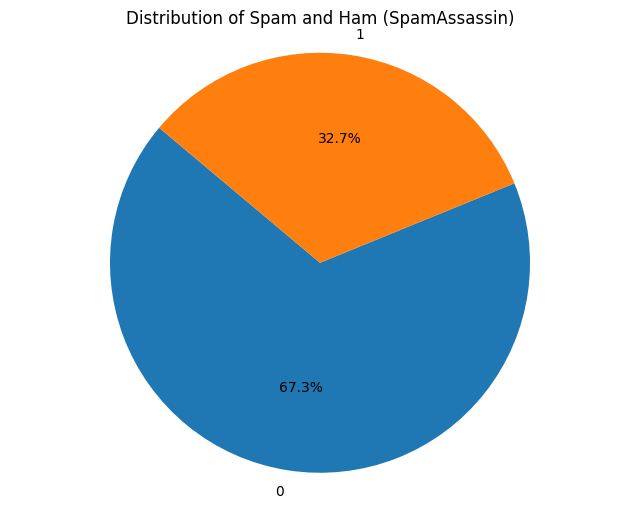

In [11]:
db['label'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(db['label'].value_counts(), labels=db['label'].value_counts().index,
        autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Spam and Ham (SpamAssassin)')
plt.axis('equal')
plt.show()


In [12]:
db.groupby("label")["emoji_count"].mean()


label
0    0.0
1    0.0
Name: emoji_count, dtype: float64

In [13]:
db.groupby('label')['num_exclamation'].mean()


label
0    0.716923
1    6.406646
Name: num_exclamation, dtype: float64

In [14]:
db.groupby('label')['num_dollar'].mean()


label
0    0.703333
1    3.906646
Name: num_dollar, dtype: float64

In [15]:
db.groupby('label')['num_question'].mean()


label
0    3.352821
1    2.674578
Name: num_question, dtype: float64

In [16]:
db.groupby('label')['num_all_caps'].mean()


label
0    16.934103
1    66.785338
Name: num_all_caps, dtype: float64

In [17]:
db.groupby('label')['capital_ratio'].mean()


label
0    0.094533
1    0.161032
Name: capital_ratio, dtype: float64

In [18]:
db.groupby('label')['num_numbers'].mean()


label
0    139.592051
1    285.142932
Name: num_numbers, dtype: float64

In [19]:
db.groupby('label')['num_urls'].mean()


label
0    3.874359
1    5.755802
Name: num_urls, dtype: float64

In [20]:
db.groupby('label')['word_count'].mean()


label
0    405.652051
1    545.647679
Name: word_count, dtype: float64

In [21]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   text             5796 non-null   str    
 1   label            5796 non-null   int64  
 2   num_urls         5796 non-null   int64  
 3   num_exclamation  5796 non-null   int64  
 4   num_question     5796 non-null   int64  
 5   num_dollar       5796 non-null   int64  
 6   num_all_caps     5796 non-null   int64  
 7   num_numbers      5796 non-null   int64  
 8   word_count       5796 non-null   int64  
 9   capital_ratio    5796 non-null   float64
 10  emoji_count      5796 non-null   int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 498.2 KB


## 6. Deduplication

Remove duplicate rows based on the `text` column to avoid data leakage.

In [22]:
db.drop_duplicates(subset="text", inplace=True)
db.shape


(5329, 11)

## 7. Text Cleaning

Import the `clean_db_text` function for heavy-duty text cleaning (bracket/hex removal, normalisation).

In [ ]:
from src.preprocess import clean_db_text


## 7b. Apply Cleaner

Apply `clean_db_text` to every row and re-deduplicate after cleaning.

In [24]:
db["text"] = db["text"].apply(clean_db_text)
db.drop_duplicates(subset="text", inplace=True)
print(f"After cleaning: {db.shape}")


After cleaning: (5328, 11)


In [25]:
db["text"].iloc[0]


"from [email] mon jul [phonenumber] [number] [phonenumber] return-path delivered-to [email] received from localhost (localhost [phonenumber] ) by phoboslabsnetnoteinccom (postfix) with esmtp id a13d [phonenumber] f for ; mon [number] jul [phonenumber] [number] [number] - [phonenumber] (edt) received from phobos [phonenumber] by localhost with imap (fetchmail- [number] [number] [number] ) for jm@localhost (single-drop); mon [number] jul [phonenumber] [number] [number] [phonenumber] (ist) received from lughtuathaorg ( [email] [phonenumber] ) by dogmaslashnullorg ( [phonenumber] / [phonenumber] ) with esmtp id g6rhn7i [phonenumber] for ; sat [number] jul [phonenumber] [number] [number] [phonenumber] received from lugh (root@localhost [phonenumber] ) by lughtuathaorg ( [number] [number] [number] / [number] [number] [number] ) with esmtp id saa [phonenumber] ; sat [number] jul [phonenumber] [number] [number] [phonenumber] x-authentication-warning lughtuathaorg host root@localhost [phonenumb

## 8. Regex Cleanup

Remove noise tokens: `[NUMBER]` placeholders, underscores, repeated `-+=` characters, and angle brackets/slashes.

In [26]:
# remove [NUMBER] token (count is already in num_numbers feature)
db["text"] = db["text"].str.replace(r'\b\[NUMBER\]\b', '', regex=True)

# remove underscores
db["text"] = db["text"].str.replace("_", "", regex=False)

# remove repeated - + =
db["text"] = db["text"].str.replace(r'[-+=]{2,}', ' ', regex=True)

# remove > < / 
db["text"] = db["text"].str.replace(r'[<>/]', '', regex=True)


## 9. Advanced Text Processing (Optional)

Apply stopword removal and stemming via `process_text_advanced`. (Cell may be left unexecuted.)

In [ ]:
from src.preprocess import process_text_advanced
db["text"] = db["text"].apply(process_text_advanced)


In [29]:
db["text"].iloc[0]


"[email] mon jul [phonenumber] [number] [phonenumber] return-path delivered-to [email] receiv localhost localhost [phonenumber] phoboslabsnetnoteinccom postfix esmtp id a13d [phonenumber] f mon [number] jul [phonenumber] [number] [number] [phonenumber] edt receiv phobo [phonenumber] localhost imap fetchmail- [number] [number] [number] jm@localhost single-drop mon [number] jul [phonenumber] [number] [number] [phonenumber] ist receiv lughtuathaorg [email] [phonenumber] dogmaslashnullorg [phonenumber] [phonenumber] esmtp id g6rhn7i [phonenumber] sat [number] jul [phonenumber] [number] [number] [phonenumber] receiv lugh root@localhost [phonenumber] lughtuathaorg [number] [number] [number] [number] [number] [number] esmtp id saa [phonenumber] sat [number] jul [phonenumber] [number] [number] [phonenumber] x-authentication-warn lughtuathaorg host root@localhost [phonenumber] claim lugh receiv mail1mailioli mail1mailioli [phonenumber] lughtuathaorg [number] [number] [number] [number] [number] 

In [30]:
db.shape


(5328, 11)

In [31]:
db["label"].value_counts()


label
0    3638
1    1690
Name: count, dtype: int64

## 10. Save Cleaned Dataset

Write the cleaned and feature-engineered dataset to the processed data directory.

In [32]:
from src.config import PROCESSED_DATA_DIR
db.to_csv(PROCESSED_DATA_DIR / "cleaned_spamassassin.csv", index=False)
print(f"Saved to {PROCESSED_DATA_DIR / 'cleaned_spamassassin.csv'}")


Saved to C:\Users\aungm\university\computing\cos30049-email-spam-detection\data\processed\cleaned_spamassassin.csv
